In [51]:
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [52]:
emnist_dataset, emnist_info = tfds.load(
    'emnist/letters',
    with_info=True,
    as_supervised=True,
)

In [53]:
emnist_train, emnist_test = emnist_dataset['train'], emnist_dataset['test']
num_validation_sample = 0.1 * emnist_info.splits['train'].num_examples
num_validation_sample

8880.0

In [54]:
num_validation_sample = tf.cast(num_validation_sample, tf.int64)

In [55]:
NUM_CLASSES = 26
LETTERS = [chr(ord('A') + i) for i in range(NUM_CLASSES)]


def scale(img, label):
    img = tf.cast(img, tf.float32)
    img = tf.transpose(img)
    img = img / 255.0
    img = tf.reshape(img, (28, 28, 1))
    label = label - 1
    return img, label


train_val_data = emnist_train.map(scale, num_parallel_calls=tf.data.AUTOTUNE)
test_data = emnist_test.map(scale, num_parallel_calls=tf.data.AUTOTUNE)

2026-07-07 10:57:35.987142: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


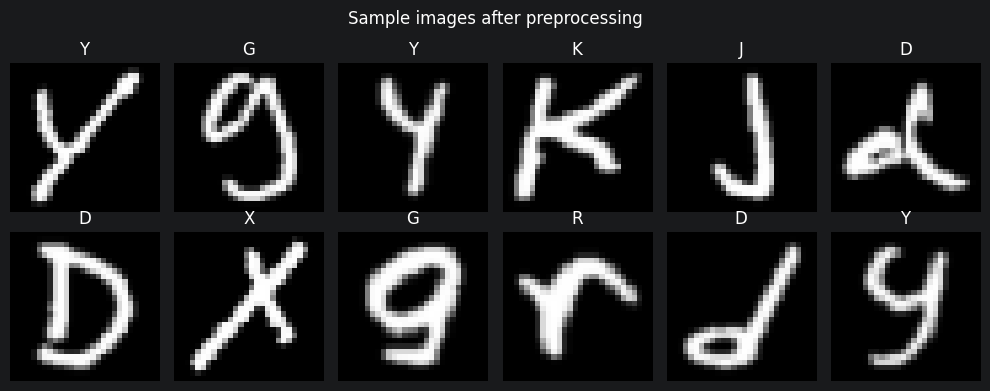

In [56]:
# Verify EMNIST orientation after transpose
sample_images, sample_labels = next(iter(train_val_data.batch(12)))

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, img, label in zip(axes.flat, sample_images, sample_labels):
    ax.imshow(img.numpy().squeeze(), cmap='gray')
    ax.set_title(LETTERS[int(label)])
    ax.axis('off')
plt.suptitle('Sample images after preprocessing')
plt.tight_layout()
plt.show()

In [57]:
BUFFER_SIZE = 10000

shuffled_tv_data = train_val_data.shuffle(BUFFER_SIZE, seed=42)
validation_data = shuffled_tv_data.take(num_validation_sample)
train_data = shuffled_tv_data.skip(num_validation_sample)

In [58]:
BATCH_SIZE = 64

train_data = train_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_data = validation_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(BATCH_SIZE)

In [59]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,818 (569.60 KB)

 Trainable params: 145,818 (569.60 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [61]:
NUM_EPOCHS = 25

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_data,
    epochs=NUM_EPOCHS,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/20
1249/1249 - 72s - 57ms/step - accuracy: 0.4480 - loss: 1.7625 - val_accuracy: 0.7971 - val_loss: 0.6593
Epoch 2/20
1249/1249 - 83s - 66ms/step - accuracy: 0.7427 - loss: 0.8105 - val_accuracy: 0.8708 - val_loss: 0.4169
Epoch 3/20
1249/1249 - 95s - 76ms/step - accuracy: 0.8048 - loss: 0.6138 - val_accuracy: 0.8885 - val_loss: 0.3449
Epoch 4/20
1249/1249 - 95s - 76ms/step - accuracy: 0.8350 - loss: 0.5188 - val_accuracy: 0.9012 - val_loss: 0.3059
Epoch 5/20
1249/1249 - 96s - 77ms/step - accuracy: 0.8539 - loss: 0.4597 - val_accuracy: 0.9162 - val_loss: 0.2505
Epoch 6/20
1249/1249 - 97s - 78ms/step - accuracy: 0.8674 - loss: 0.4193 - val_accuracy: 0.9196 - val_loss: 0.2355
Epoch 7/20
1249/1249 - 97s - 78ms/step - accuracy: 0.8741 - loss: 0.3964 - val_accuracy: 0.9242 - val_loss: 0.2135
Epoch 8/20
1249/1249 - 98s - 78ms/step - accuracy: 0.8799 - loss: 0.3745 - val_accuracy: 0.9268 - val_loss: 0.2068
Epoch 9/20
1249/1249 - 99s - 80ms/step - accuracy: 0.8867 - loss: 0.3510 - val_a

In [62]:
test_loss, test_acc = model.evaluate(test_data)
print('\nTest accuracy:', test_acc)

232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9209 - loss: 0.2252

Test accuracy: 0.9208783507347107


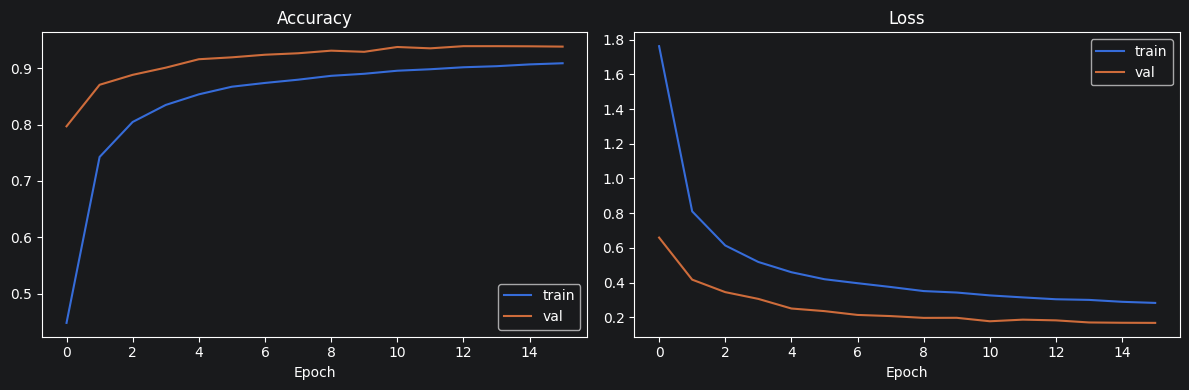

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

2026-07-07 11:25:55.171299: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


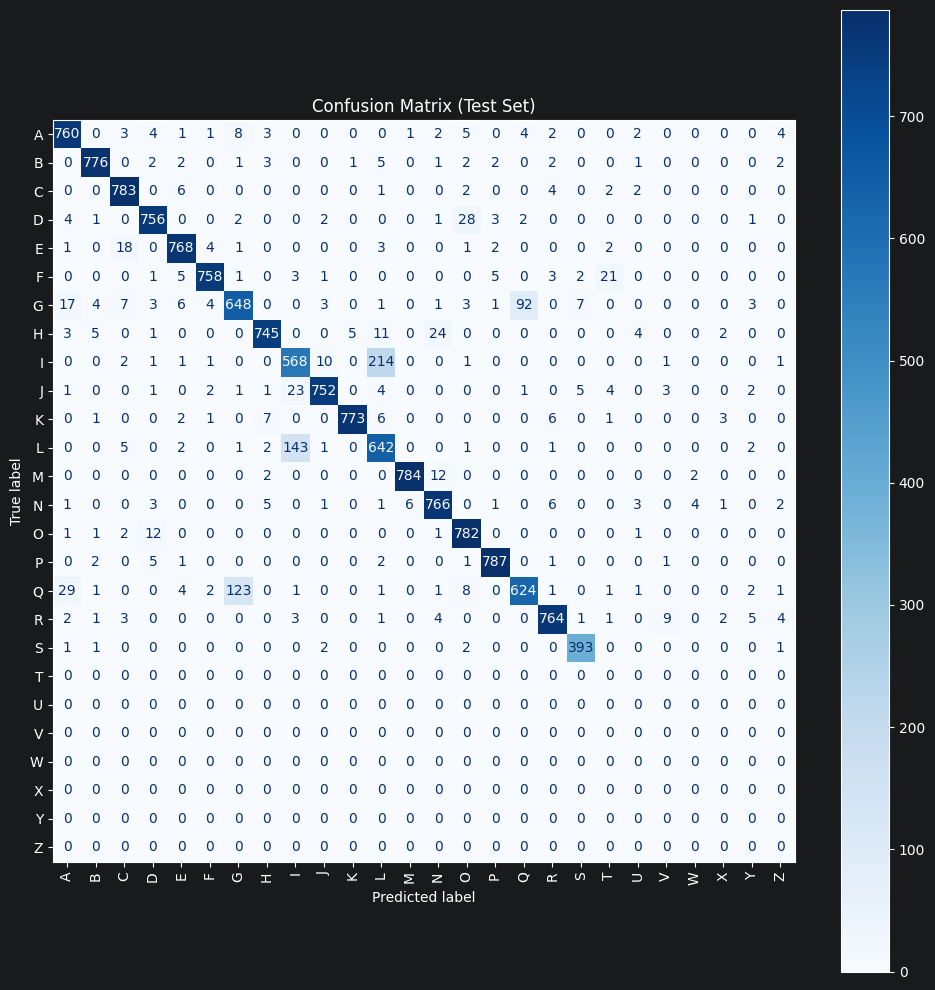

Lowest per-class accuracy:
  I: 71.00%
  Q: 78.00%
  L: 80.25%
  G: 81.00%
  H: 93.12%


/var/folders/7c/lq4bm735423dshfysxglzw080000gn/T/ipykernel_24077/3259598706.py:17: RuntimeWarning: invalid value encountered in divide
  per_class_acc = cm.diagonal() / cm.sum(axis=1)


In [64]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=LETTERS).plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_classes = np.argsort(per_class_acc)[:5]
print('Lowest per-class accuracy:')
for idx in worst_classes:
    print(f'  {LETTERS[idx]}: {per_class_acc[idx]:.2%}')

In [65]:
save_path = '../backend/saved_models/character_model.keras'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
model.save(save_path)
print(f'Model saved to {save_path}')

Model saved to ../backend/saved_models/emnist_cnn.keras
